Number of pedestrians detected: 7


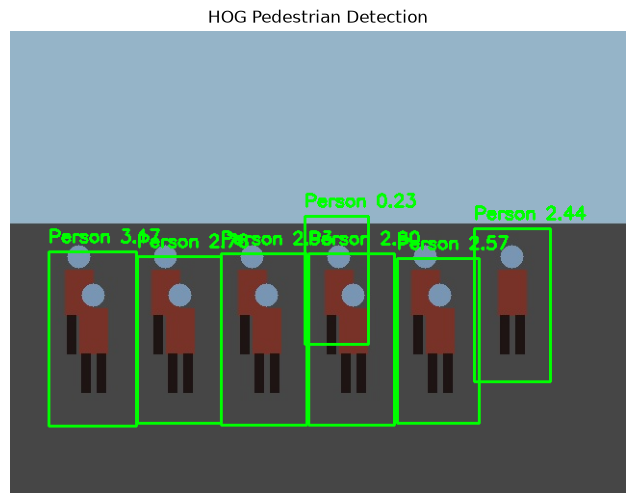

In [1]:
#Write a program using OpenCV to detect pedestrians in an image using the HOG 
#(Histogram of Oriented Gradients) descriptor. 
import cv2
import matplotlib.pyplot as plt
import os

# Read image
image_path = "road1.jpg"
if not os.path.exists(image_path) and os.path.exists("sample_data/road1.jpg"):
    image_path = "sample_data/road1.jpg"

image = cv2.imread(image_path)

if image is None:
    print("Image not found!")
    exit()

# Create HOG descriptor
hog = cv2.HOGDescriptor()

# Load OpenCV's pre-trained people detector
hog.setSVMDetector(
    cv2.HOGDescriptor_getDefaultPeopleDetector()
)
# Detect pedestrians
rects, weights = hog.detectMultiScale(
    image,
    winStride=(4, 4),
    padding=(8, 8),
    scale=1.03
)
# Draw bounding boxes
for (x, y, w, h), weight in zip(rects, weights):
    cv2.rectangle(
        image,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )
    cv2.putText(
        image,
        f"Person {float(weight):.2f}",
        (x, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2
    )
print("Number of pedestrians detected:", len(rects))

try:
    cv2.imshow("HOG Pedestrian Detection", image)
    cv2.waitKey(1)
    cv2.destroyAllWindows()
except Exception:
    pass

plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("HOG Pedestrian Detection")
plt.axis("off")
plt.show()
